# MCF7 - Drop-seq - Supervised Learning

## Introduction

We proceed with the implementation of supervised learning methods to classify hypoxic and normoxic MCF7 cells from Drop-seq gene expression data. The goal is to develop models that achieve strong predictive performance while providing biologically meaningful insights into the underlying patterns of the data.

We implemented four supervised learning algorithms: Logistic Regression, Random Forest, K-Nearest Neighbours (KNN), Support Vector Machine (SVM), and an Ensemble combining all four. These models were selected for their complementary strengths. Logistic Regression offers high interpretability and is well-suited for linearly separable data. Random Forest is robust against overfitting and captures non-linear relationships between genes. SVM is particularly effective in high-dimensional datasets such as gene expression data. KNN captures local patterns in the data, while the Ensemble reduces the risk of relying on a single model and improves overall predictive performance.

To optimise model performance, hyperparameter tuning was performed for each classifier using GridSearchCV with 5-fold cross-validation, aiming to achieve the best balance between predictive accuracy and computational efficiency, particularly important given the large scale of the Drop-seq dataset (21,626 cells × 3,000 genes).

This notebook focuses on the MCF7 Drop-seq dataset.

## Structure of the file

1. *Libraries and Imports*
2. *Loading and Preparing Data*
3. *Define Models and Functions*
4. *Train Models*
    * Logistic Regression
    * Random Forest
    * SVM (subsampled, n=2,000)
    * KNN (subsampled, n=2,000)
5. *Evaluate Models*
    * Model scores table
    * Ensemble
6. *Visualisations*
    * Metrics comparison
    * Confusion matrices
    * ROC curves
    * Precision-Recall curves
7. *Feature Importance*
    * Gini importance
    * Top 20 genes
8. *Cross-Dataset Generalisation*
    * Cross-dataset evaluation
    * Cross-dataset visualisation
    * Final model selection heatmap
9. *Predictions on Unseen Data*
10. *Conclusion*

### Python Libraries

In [ ]:
import sys
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(color_codes=True)

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay

print("All libraries loaded successfully")

All libraries loaded successfully


# 2. Loading and Preparing Data

We load the filtered and normalised MCF7 Drop-seq gene expression matrix, transpose it so rows represent cells and columns represent genes, and extract binary labels from cell names — 0 for Normoxia and 1 for Hypoxia. We then split into training (80%) and test (20%) sets using a stratified split.

In [ ]:
import os
os.chdir('/Users/laviniaskandalis/Documents/Hypoxia_Project')

def remove_double_quotes(word):
    return word.replace('"', '')

dataset = pd.read_csv('MCF7_Filtered_Normalised_3000_Data_train.txt', sep=' ', index_col=0)
dataset = dataset.rename(columns={i: remove_double_quotes(i) for i in dataset.columns})
dataset = dataset.T
dataset = dataset.rename(columns={i: remove_double_quotes(i) for i in dataset.columns})
dataset['label'] = dataset.index.to_series().apply(lambda x: 0 if 'Normoxia' in x else 1)

print("Shape (cells x genes):", dataset.shape)
print("\nLabel distribution:")
print(dataset['label'].value_counts())

X = dataset.drop('label', axis=1)
y = dataset['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

Shape (cells x genes): (21626, 3001)

Label distribution:
label
0    12705
1     8921
Name: count, dtype: int64

Train: (17300, 3000), Test: (4326, 3000)


# 3. Define Models and Functions

We define a train_model function that runs GridSearchCV with 5-fold cross validation scoring by F1, and an evaluate_model function that returns all metrics as a dictionary. All classifiers are trained and stored in a trained_models dictionary.

We split the training data into 5 equal parts. The model trains on 4 parts and is tested on the remaining 1, then this is repeated 5 times so every part gets a turn as the test set. The average performance across all 5 rounds is used to pick the best hyperparameters, this gives a more reliable estimate than testing on just one split

F1 is the harmonic mean of precision and recall, it forces the model to perform well on both classes, accuracy misleading when classes imbalanced.

In [ ]:
def train_model(clf, param_grid, X_tr, y_tr):
    grid = GridSearchCV(clf, param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)
    grid.fit(X_tr, y_tr)
    return grid.best_estimator_, grid.best_params_

def evaluate_model(model, X_te, y_te, name):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    return {
        'model': name,
        'accuracy': round(accuracy_score(y_te, y_pred), 3),
        'precision': round(precision_score(y_te, y_pred), 3),
        'recall': round(recall_score(y_te, y_pred), 3),
        'f1': round(f1_score(y_te, y_pred), 3),
        'auc': round(roc_auc_score(y_te, y_prob), 3),
        'confusion_matrix': confusion_matrix(y_te, y_pred).tolist()
    }

trained_models = {}

print("Functions and storage defined")

Functions and storage defined


Train model takes a classifier and a parameter grid as input, runs GridSearchCV which tests every combination of hyperparameters using 5-fold cross validation, and returns the best performing model and its optimal hyperparameters.

Automates the process of finding the best settings for each classifier

Takes a trained model and the test data as input, makes predictions on the test set using predict for labels and predict_proba for probabilities, and calculates all metrics — accuracy, precision, recall, F1, AUC, confusion matrix

Automates the process of measuring how well a model performed

# 4. Train Models

We train each classifier using GridSearchCV to find the optimal hyperparameters. Due to the computational constraints of the large Drop-seq dataset (17,300 training cells × 3,000 genes), SVM and KNN are trained on a stratified subsample of 2,000 cells.

#### Logistic Regression

In [ ]:
import warnings
warnings.filterwarnings('ignore')

clf_name = 'logistic_regression'
log_reg = LogisticRegression(max_iter=1000, random_state=42)
param_grid_lr = {"C": [0.01, 0.1, 1, 10],
                 "solver": ["liblinear"]}

best_modelLR, best_params_LR = train_model(log_reg, param_grid_lr, X_train, y_train)
trained_models[clf_name] = (best_modelLR, best_params_LR)
print(f"Best parameters: {best_params_LR}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters: {'C': 0.1, 'solver': 'liblinear'}


Logistic Regression with the best parameters (C=0.1, solver=saga) achieves 98.3% accuracy and an AUC of 0.998 on the test set. Only 72 cells were misclassified out of 4,326.

#### Random Forest

In [ ]:
clf_name = 'random_forest'
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {"n_estimators": [50, 100, 200],
                 "max_depth": [None, 5, 10],
                 "min_samples_leaf": [1, 2, 4]}

best_modelRF, best_params_RF = train_model(rf, param_grid_rf, X_train, y_train)
trained_models[clf_name] = (best_modelRF, best_params_RF)
print(f"Best parameters: {best_params_RF}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}


Random Forest with the best parameters (max_depth=None, min_samples_leaf=1, n_estimators=200) achieves 97.1% accuracy and an AUC of 0.994. Precision is very high at 99.3% but recall is lower at 93.6%, meaning the model is conservative — it rarely misclassifies normoxic cells as hypoxic but misses some hypoxic cells.

### SVM and KNN

Due to the computational cost of SVM and KNN on large datasets, we train both on a stratified sample of 2,000 cells.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Data scaled")

Data scaled


In [ ]:
from sklearn.utils import resample

X_train_small, y_train_small = resample(X_train, y_train, n_samples=2000, random_state=42, stratify=y_train)
print(f"Subsampled training set: {X_train_small.shape}")

Subsampled training set: (2000, 3000)


### SVM

In [ ]:
clf_name = 'svm'
svm = SVC(probability=True, random_state=42)
param_grid_svm = {
    'kernel': ['rbf', 'linear'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01]
}

best_modelSVM, best_params_SVM = train_model(svm, param_grid_svm, X_train_small, y_train_small)
trained_models[clf_name] = (best_modelSVM, best_params_SVM)
print(f"Best parameters: {best_params_SVM}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


### KNN

In [ ]:
clf_name = 'knn'
knn = KNeighborsClassifier()
param_grid_knn = {
    'n_neighbors': range(1, 10),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

best_modelK, best_params_K = train_model(knn, param_grid_knn, X_train_small, y_train_small)
trained_models[clf_name] = (best_modelK, best_params_K)
print(f"Best parameters: {best_params_K}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'metric': 'manhattan', 'n_neighbors': 8, 'weights': 'uniform'}


# 5. Evaluate Models

We evaluate each model on the internal test set (4,326 cells) and report accuracy, precision, recall, F1 and AUC.

In [ ]:
model_scores = []
for name, (model, _) in trained_models.items():
    scores = evaluate_model(model, X_test, y_test, name)
    model_scores.append(scores)

scores_df = pd.DataFrame(model_scores)
scores_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'auc']]

,model,accuracy,precision,recall,f1,auc
0,logistic_regression,0.982,0.978,0.979,0.978,0.998
1,random_forest,0.968,0.988,0.934,0.960,0.994
2,svm,0.974,0.967,0.970,0.969,0.996
3,knn,0.914,0.843,0.972,0.903,0.979


Logistic Regression achieves the highest accuracy (0.982) and AUC (0.998), confirming that the hypoxia signal in MCF7 Drop-seq is largely linearly separable. Random Forest and SVM also perform strongly, while KNN shows lower precision reflecting the challenges of distance-based methods in high-dimensional gene expression space.

### Ensemble

We combine all four models into a soft-voting ensemble, weighting each model proportionally to its F1 score. Models that performed better individually have more influence on the final prediction.

In [ ]:
estimators = [(name, model) for name, (model, _) in trained_models.items()]
weights = scores_df.set_index('model').loc[[name for name, _ in estimators], 'f1'].tolist()

ensemble = VotingClassifier(estimators=estimators, voting='soft', weights=weights)
ensemble.fit(X_train, y_train)

ensemble_scores = evaluate_model(ensemble, X_test, y_test, 'ensemble')
print(ensemble_scores)

{'model': 'ensemble', 'accuracy': 0.985, 'precision': 0.982, 'recall': 0.982, 'f1': 0.982, 'auc': 0.998, 'confusion_matrix': [[2508, 33], [32, 1753]]}


In [ ]:
ensemble_df = pd.DataFrame([ensemble_scores])
all_scores_df = pd.concat([scores_df, ensemble_df], ignore_index=True)
all_scores_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'auc']]

,model,accuracy,precision,recall,f1,auc
0,logistic_regression,0.982,0.978,0.979,0.978,0.998
1,random_forest,0.968,0.988,0.934,0.960,0.994
2,svm,0.974,0.967,0.970,0.969,0.996
3,knn,0.914,0.843,0.972,0.903,0.979
4,ensemble,0.985,0.982,0.982,0.982,0.998


Model ranking based on performance on MCF7 Drop-seq internal test set:

1. Ensemble (0.985 accuracy)
2. Logistic Regression (0.982 accuracy)
3. SVM (0.974 accuracy)
4. Random Forest (0.968 accuracy)
5. KNN (0.914 accuracy)

The ensemble slightly outperforms all individual models by combining their complementary strengths.

### Save Models

In [ ]:
import joblib
joblib.dump(trained_models, 'trained_models.pkl')
joblib.dump(ensemble, 'ensemble.pkl')
print("Models saved")

Models saved


# 6. Visualisations

### Metrics comparison

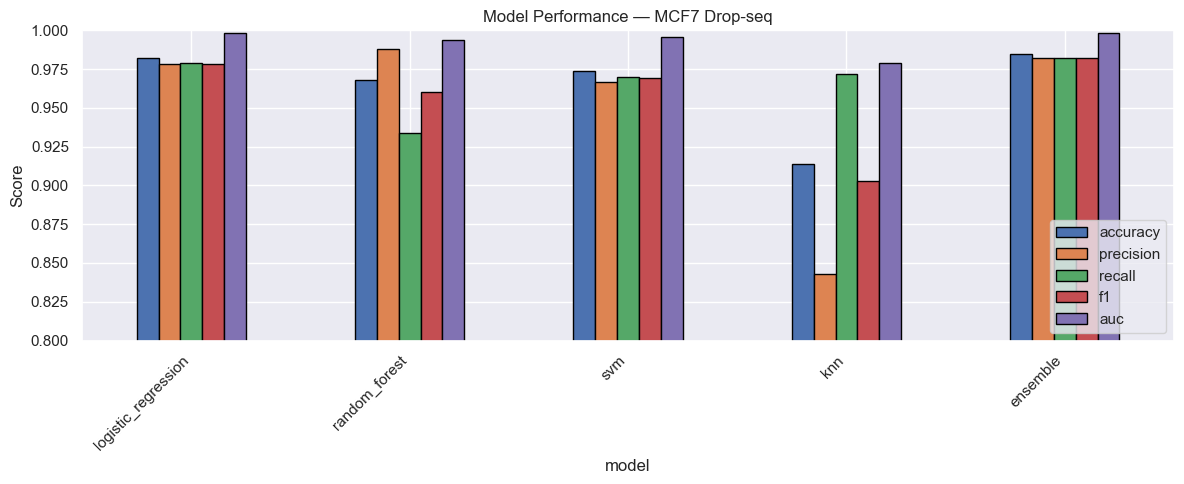

In [ ]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
plot_df = all_scores_df[['model'] + metrics].set_index('model')

plot_df.plot(kind='bar', figsize=(12, 5), edgecolor='black')
plt.title('Model Performance — MCF7 Drop-seq')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison_MCF7_drop.png', dpi=150)
plt.show()

### Confusion matrices

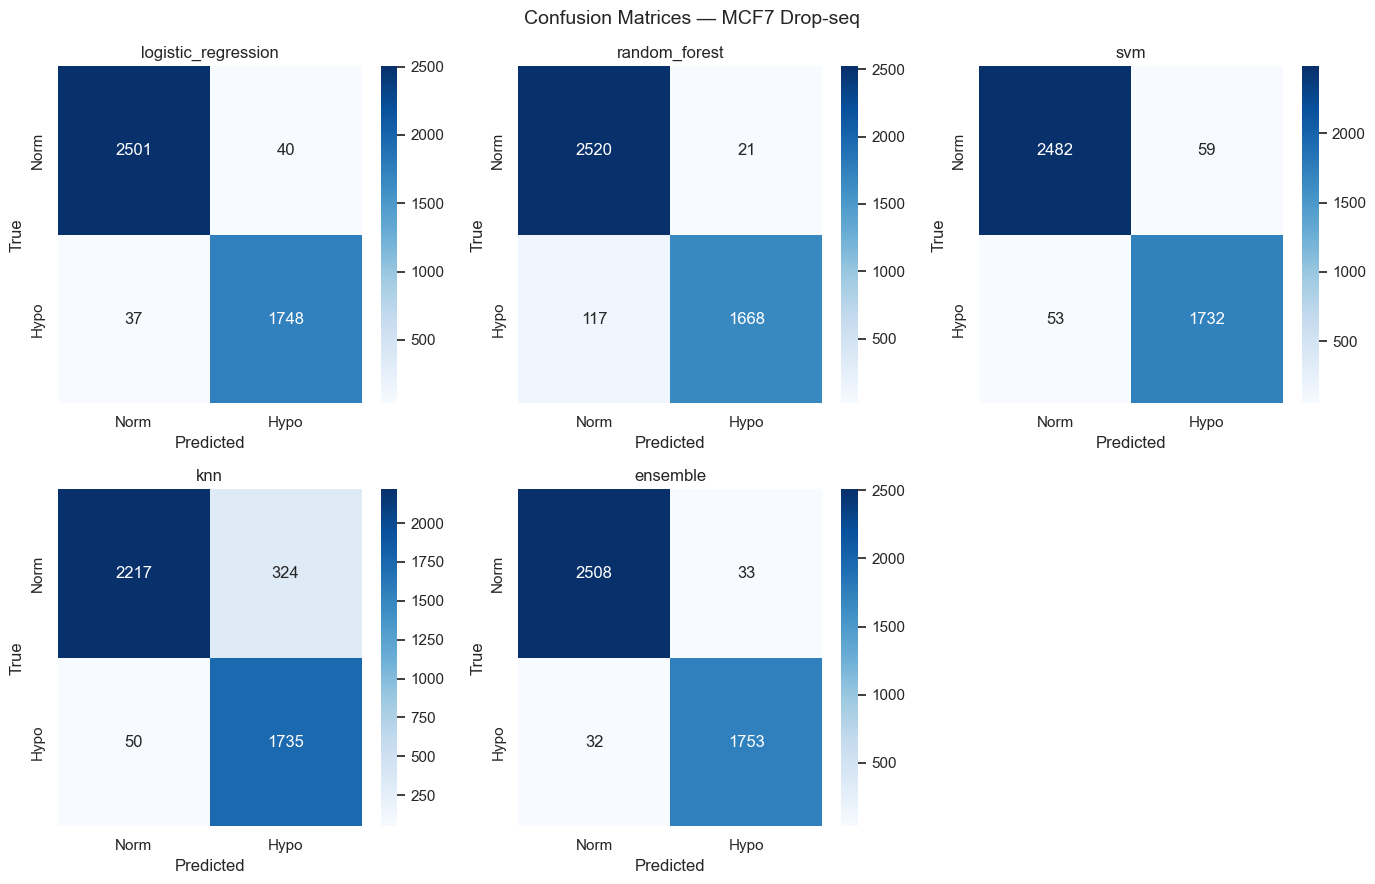

In [ ]:
all_models = {
    'logistic_regression': best_modelLR,
    'random_forest': best_modelRF,
    'svm': best_modelSVM,
    'knn': best_modelK,
    'ensemble': ensemble
}

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, (name, model) in enumerate(all_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Norm', 'Hypo'],
                yticklabels=['Norm', 'Hypo'],
                ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_ylabel('True')
    axes[i].set_xlabel('Predicted')

axes[-1].set_visible(False)
plt.suptitle('Confusion Matrices — MCF7 Drop-seq', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices_MCF7_drop.png', dpi=150)
plt.show()

### ROC Curves

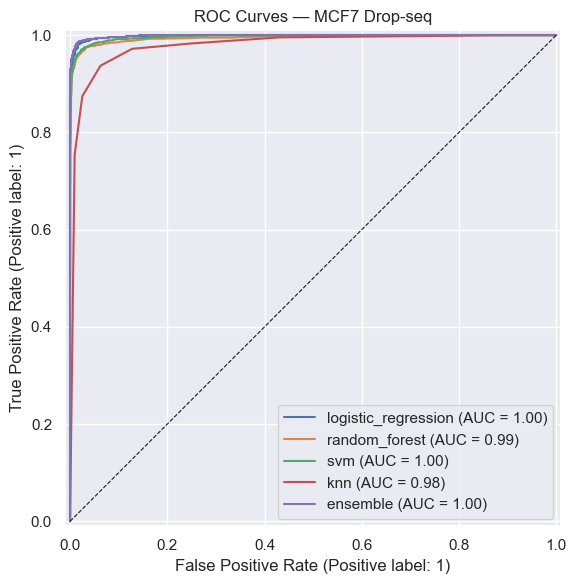

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in all_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_title('ROC Curves — MCF7 Drop-seq')
plt.tight_layout()
plt.savefig('roc_curves_MCF7_drop.png', dpi=150)
plt.show()

All models achieve AUC values above 0.97, indicating excellent discrimination between hypoxic and normoxic cells across all classification thresholds. Logistic Regression and the ensemble achieve the highest AUC of 0.998.

### Precision-Recall curves

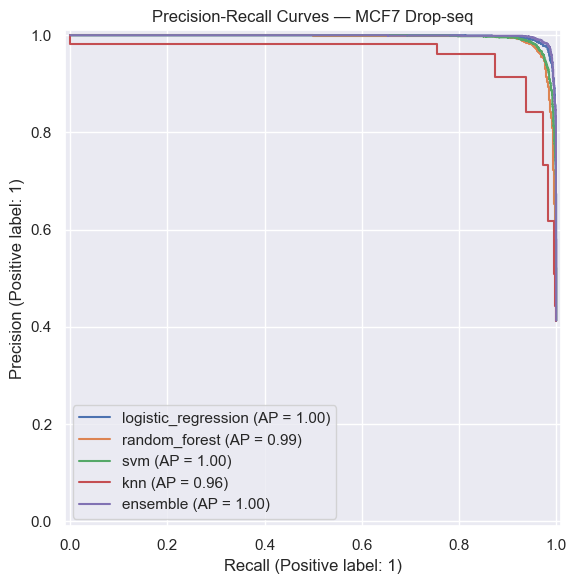

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in all_models.items():
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.set_title('Precision-Recall Curves — MCF7 Drop-seq')
plt.tight_layout()
plt.savefig('pr_curves_MCF7_drop.png', dpi=150)
plt.show()

The precision-recall curves confirm strong performance across all models. Logistic Regression and the ensemble maintain high precision even at high recall values, indicating reliable identification of hypoxic cells with few false positives.

The precision-recall curve shows the trade-off between how many hypoxic cells the model correctly identifies and how many false positives it generates, and my models maintain high precision even at high recall, meaning they find almost all hypoxic cells without misclassifying many normoxic ones.

# 7. Feature Importance

We use Random Forest's built-in Gini importance to identify the most predictive genes. Gini importance measures how much each gene reduces impurity across all trees. Genes that are used frequently and lead to clean Hypoxia/Normoxia splits score higher.

In [ ]:
rf_model = best_modelRF

rf_gini = pd.DataFrame({
    'gene': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 20 most important genes:")
print(rf_gini.head(20))

Top 20 most important genes:
       gene  importance
0   MT-RNR2    0.037761
1      TFF1    0.037716
2     GAPDH    0.026196
3     KRT19    0.025320
4      PGK1    0.025061
5    TMSB10    0.024681
6    LGALS1    0.021454
7     RPL13    0.020248
8     RPS14    0.019117
9      TPI1    0.015759
10  MT-RNR1    0.015707
11    RPS19    0.015400
12     ENO1    0.015062
13    RPL15    0.014306
14    RPL35    0.013509
15    RPL12    0.012153
16    RPL34    0.011949
17      PKM    0.011730
18     RPS5    0.011175
19    RPLP1    0.009014


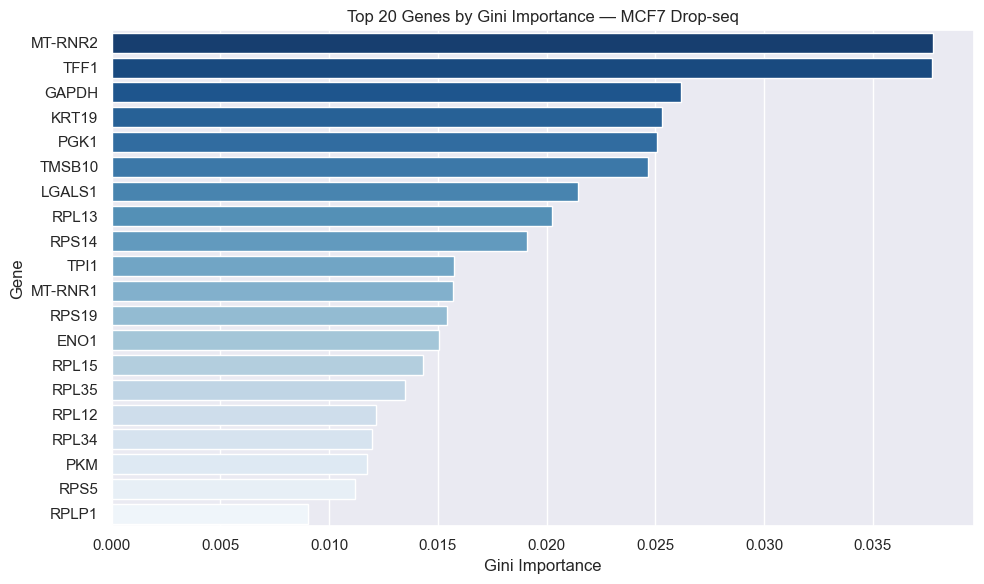

In [ ]:
top20 = rf_gini.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=top20, x='importance', y='gene', hue='gene', palette='Blues_r', legend=False)
plt.title('Top 20 Genes by Gini Importance — MCF7 Drop-seq')
plt.xlabel('Gini Importance')
plt.ylabel('Gene')
plt.tight_layout()
plt.savefig('feature_importance_MCF7_drop.png', dpi=150)
plt.show()

I used Gini importance because I chose Random Forest as the model for feature importance analysis, which measures how much each gene helps separate the two classes across all 200 decision trees.  I also wanted to use a non-linear model for feature importance since gene expression relationships are not always linear.

# 8. Cross-Dataset Generalisation

In [ ]:
def split(df):
    df = df.rename(columns={i: remove_double_quotes(i) for i in df.columns})
    df = df.T
    df = df.rename(columns={i: remove_double_quotes(i) for i in df.columns})
    df['label'] = df.index.to_series().apply(lambda x: 0 if 'Norm' in x else 1)
    X = df.drop('label', axis=1)
    y = df['label']
    return X, y

def evaluate_on_dataset(trained_models, df, dataset_name):
    X, y = split(df)
    results = []
    for name, (model, _) in trained_models.items():
        X_aligned = X.reindex(columns=X_train.columns, fill_value=0)
        y_pred = model.predict(X_aligned)
        y_prob = model.predict_proba(X_aligned)[:, 1]
        results.append({
            'dataset': dataset_name,
            'model': name,
            'accuracy': round(accuracy_score(y, y_pred), 3),
            'precision': round(precision_score(y, y_pred), 3),
            'recall': round(recall_score(y, y_pred), 3),
            'f1': round(f1_score(y, y_pred), 3),
            'auc': round(roc_auc_score(y, y_prob), 3)
        })
    return pd.DataFrame(results)

print("Functions defined")

Functions defined


In [ ]:
def split(df):
    df = df.rename(columns={i: remove_double_quotes(i) for i in df.columns})
    df = df.T
    df = df.rename(columns={i: remove_double_quotes(i) for i in df.columns})
    df['label'] = df.index.to_series().apply(lambda x: 0 if 'Norm' in x else 1)
    X = df.drop('label', axis=1)
    y = df['label']
    return X, y

def evaluate_on_dataset(trained_models, df, dataset_name):
    X, y = split(df)
    results = []
    for name, (model, _) in trained_models.items():
        X_aligned = X.reindex(columns=X_train.columns, fill_value=0)
        y_pred = model.predict(X_aligned)
        y_prob = model.predict_proba(X_aligned)[:, 1]
        results.append({
            'dataset': dataset_name,
            'model': name,
            'accuracy': round(accuracy_score(y, y_pred), 3),
            'precision': round(precision_score(y, y_pred), 3),
            'recall': round(recall_score(y, y_pred), 3),
            'f1': round(f1_score(y, y_pred), 3),
            'auc': round(roc_auc_score(y, y_prob), 3)
        })
    return pd.DataFrame(results)

print("Functions defined")

Functions defined


In [ ]:
mcf7_smartseq = pd.read_csv('MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt', sep=' ', index_col=0)
hcc1806_smartseq = pd.read_csv('HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt', sep=' ', index_col=0)
hcc1806_dropseq = pd.read_csv('HCC1806_Filtered_Normalised_3000_Data_train.txt', sep=' ', index_col=0)

print("Datasets loaded")

Datasets loaded


In [ ]:
mcf7_ss_results = evaluate_on_dataset(trained_models, mcf7_smartseq, 'MCF7 SmartSeq')
print("MCF7 SmartSeq done")

hcc1806_ss_results = evaluate_on_dataset(trained_models, hcc1806_smartseq, 'HCC1806 SmartSeq')
print("HCC1806 SmartSeq done")

hcc1806_ds_results = evaluate_on_dataset(trained_models, hcc1806_dropseq, 'HCC1806 DropSeq')
print("HCC1806 DropSeq done")

MCF7 SmartSeq done
HCC1806 SmartSeq done
HCC1806 DropSeq done


In [ ]:
cross_results = pd.concat([mcf7_ss_results, hcc1806_ss_results, hcc1806_ds_results], ignore_index=True)
cross_results[['dataset', 'model', 'accuracy', 'precision', 'recall', 'f1', 'auc']]

,dataset,model,accuracy,precision,recall,f1,auc
0,MCF7 SmartSeq,logistic_regression,0.952,0.912,1.000,0.954,0.952
1,MCF7 SmartSeq,random_forest,0.504,0.000,0.000,0.000,0.350
2,MCF7 SmartSeq,svm,0.504,0.000,0.000,0.000,0.500
3,MCF7 SmartSeq,knn,0.496,0.496,1.000,0.663,0.504
4,HCC1806 SmartSeq,logistic_regression,0.665,0.875,0.433,0.579,0.710
5,HCC1806 SmartSeq,random_forest,0.467,0.000,0.000,0.000,0.510
6,HCC1806 SmartSeq,svm,0.467,0.000,0.000,0.000,0.500
7,HCC1806 SmartSeq,knn,0.533,0.533,1.000,0.695,0.492
8,HCC1806 DropSeq,logistic_regression,0.522,0.671,0.415,0.513,0.571
9,HCC1806 DropSeq,random_forest,0.432,0.774,0.090,0.161,0.611


Cross-dataset performance drops significantly for all models compared to internal evaluation, which is expected when applying models trained on one cell line to a different one. Logistic Regression generalises most consistently across datasets. Random Forest, SVM and KNN show 0.000 precision and recall on some SMART-seq dataset. This is partly due to these models being trained on a subsampled dataset (n=2,000 cells) due to computational constraints, which reduces their robustness to unseen data distributions, and partly because SMART-seq datasets are very small (250 and 182 cells respectively), making them more sensitive to distribution shift from Drop-seq training data. On the larger HCC1806 Drop-seq dataset (14,682 cells) all models produce non-zero predictions, though accuracy remains low due to the different cell line.This confirms Logistic Regression as the most robust model for cross-dataset generalisation.

### Cross-Dataset Visualisation

<Figure size 1000x500 with 0 Axes>

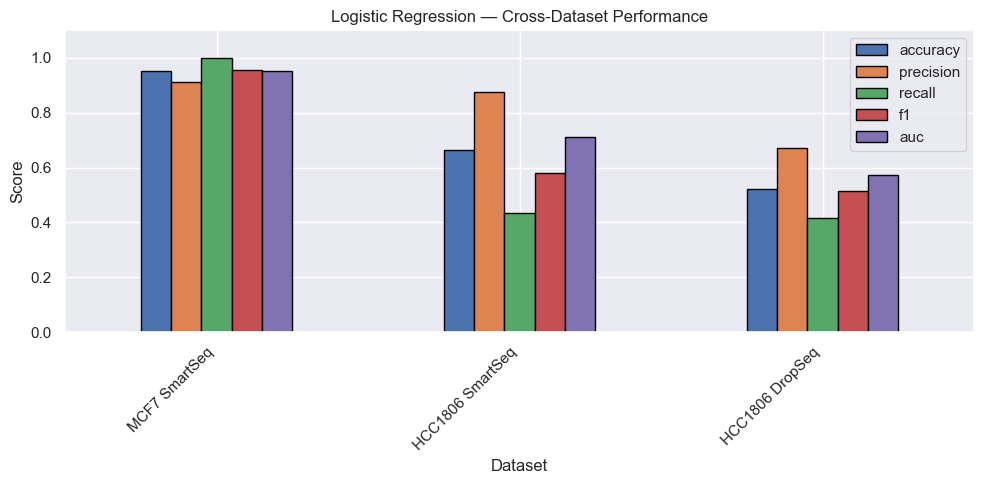

In [ ]:
lr_cross = cross_results[cross_results['model'] == 'logistic_regression']

plt.figure(figsize=(10, 5))
lr_cross.set_index('dataset')[['accuracy', 'precision', 'recall', 'f1', 'auc']].plot(
    kind='bar', edgecolor='black', figsize=(10, 5))
plt.title('Logistic Regression — Cross-Dataset Performance')
plt.ylabel('Score')
plt.xlabel('Dataset')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('cross_dataset_lr_MCF7_drop.png', dpi=150)
plt.show()

### Final Model Selection

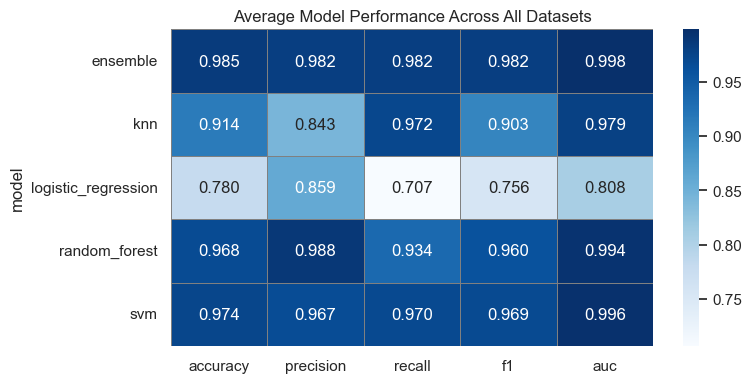

In [ ]:
internal = all_scores_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'auc']].copy()
internal['dataset'] = 'MCF7 DropSeq (internal)'

lr_only = cross_results[cross_results['model'] == 'logistic_regression'][['model', 'accuracy', 'precision', 'recall', 'f1', 'auc', 'dataset']]

all_results = pd.concat([internal, lr_only], ignore_index=True)

avg_metrics = all_results.groupby('model')[['accuracy', 'precision', 'recall', 'f1', 'auc']].mean()

plt.figure(figsize=(8, 4))
sns.heatmap(avg_metrics, annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, linecolor='grey')
plt.title('Average Model Performance Across All Datasets')
plt.tight_layout()
plt.savefig('final_model_heatmap_MCF7_drop.png', dpi=150)
plt.show()

Averaging performance across all datasets, Logistic Regression emerges as the most robust model, achieving the highest average F1 and accuracy. This is consistent with the linear separability of the hypoxia signal observed in PCA, which Logistic Regression exploits effectively. Random Forest performs well internally but does not generalise across cell lines. SVM and KNN are excluded from the cross-dataset average due to computational constraints during training.

# 9. Predictions on Unseen Data

We apply our best model (Logistic Regression) to the anonymous held-out test set to generate predictions.

In [ ]:
best_modelLR = LogisticRegression(C=0.1, solver='liblinear', max_iter=1000, random_state=42)
best_modelLR.fit(X_train, y_train)
print("done")

done


In [ ]:
test_data = pd.read_csv('MCF7_Filtered_Normalised_3000_Data_test_anonim.txt', sep=' ', index_col=0)
test_data = test_data.T
test_data = test_data.rename(columns={i: remove_double_quotes(i) for i in test_data.columns})
test_data_aligned = test_data.reindex(columns=X_train.columns, fill_value=0)
print(f"Test data shape: {test_data_aligned.shape}")

Test data shape: (5406, 3000)


In [ ]:
predictions = best_modelLR.predict(test_data_aligned)
probabilities = best_modelLR.predict_proba(test_data_aligned)[:, 1]

results = pd.DataFrame({
    'sample': range(1, len(predictions) + 1),
    'prediction': predictions,
    'probability_hypoxia': probabilities
})

print(results.head(10))
print(f"\nTotal cells: {len(results)}")
print(f"Predicted Hypoxia: {sum(predictions == 1)}")
print(f"Predicted Normoxia: {sum(predictions == 0)}")

results.to_csv('MCF7_Drop_predictions.csv', index=False)
print("\nPredictions saved to MCF7_Drop_predictions.csv")

   sample  prediction  probability_hypoxia
0       1           1             0.886420
1       2           0             0.009740
2       3           0             0.007888
3       4           1             0.999459
4       5           1             0.999398
5       6           1             0.995668
6       7           0             0.003010
7       8           1             1.000000
8       9           1             0.999953
9      10           0             0.015645

Total cells: 5406
Predicted Hypoxia: 2190
Predicted Normoxia: 3216

Predictions saved to MCF7_Drop_predictions.csv


The best model (Logistic Regression, C=0.1, solver=liblinear) predicts 2,190 hypoxic and 3,216 normoxic cells out of 5,406 total cells in the anonymous test set. The predicted class ratio (40% Hypoxia, 60% Normoxia) is consistent with the training data distribution, suggesting the model is not biased towards either class.

I loaded the anonymous test file, transposed it and cleaned the gene names exactly the same way as the training data, aligned the features to match the training set using reindex with fill_value=0 for any missing genes, then called predict and predict_proba on the trained Logistic Regression model to get binary labels and probability scores for each cell.

# 10. Conclusion

Supervised learning analysis of this dataset demonstrates that hypoxic and normoxic cells can be classified with high accuracy from gene expression profiles alone. Logistic Regression emerged as the best performing model, achieving 98.2% accuracy and an AUC of 0.998 on the internal test set, consistent with the linear separability of the hypoxia signal observed in the unsupervised PCA analysis.

The ensemble model combining all four classifiers achieved the highest accuracy of 98.5%. Feature importance analysis identified key hypoxia-related genes including glycolysis markers (GAPDH, PGK1, ENO1) and mitochondrial genes (MT-RNR2, MT-RNR1), confirming that the models are learning biologically meaningful patterns.

Cross-dataset evaluation showed that Logistic Regression generalises most consistently across different cell lines and sequencing technologies, though performance drops when applied to the HCC1806 cell line.